# SI 385 Homework 6
### Lia Du

In [2]:
#helpful doc: https://www.kaggle.com/adamschroeder/countvectorizer-tfidfvectorizer-predict-comments

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sentence_transformers import SentenceTransformer
import spacy

# Classification libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report
from sklearn.svm import LinearSVC
import subprocess

## Q1. Text Pre-processing and Feature Extraction 
- Load and clean the data
- Perform some EDA
- Extract features for classification using TF-IDF and Sentence Transformers

#### 1a) Load the Kaggle dataset CSV and report number of rows, column names, and label distribution (1pt)

In [4]:
# Insert code here

fake = pd.read_csv("WELFake_Dataset.csv")
print(f"Number of rows: {len(fake)}, Number of columns: {fake.shape[1]}")
print(f"column names: {fake.columns.tolist()}")
print(f"label distribution: \n{fake['label'].value_counts(dropna=False)}")
fake.head()

Number of rows: 72134, Number of columns: 4
column names: ['Unnamed: 0', 'title', 'text', 'label']
label distribution: 
label
1    37106
0    35028
Name: count, dtype: int64


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


#### 1b. Clean the data for feature extraction and classification. 
- Handling missing values
- Handling duplicate rows
- Choosing columns for extraction

In [5]:
# Insert code here

fake['title'] = fake['title'].fillna('')
fake['text'] = fake['text'].fillna('')
fake['content'] = (fake['title'] + " . " + fake['text']).str.strip()
fake['content'] = fake['content'].str.lower()

initial_len = len(fake)
fake = fake[fake['content'].str.strip() != ""].copy()
print(f"dropped {initial_len - len(fake)} empty rows")

before_dup = len(fake)
fake = fake.drop_duplicates(subset=['content', 'label'])
print(f"removed {before_dup - len(fake)} duplicate rows")

fake['label'] = fake['label'].astype(int)

print(f"final rows: \n{fake['label'].value_counts(dropna=False)}")

dropped 0 empty rows
removed 8459 duplicate rows
final rows: 
label
0    34790
1    28885
Name: count, dtype: int64


I combined title + text into a single content field (titles are informative), then I dropped rows where both title and text were missing. I filled NaN title/text entries with empty strings before combining. I then removed exact duplicate rows and converted label to integers (if it was necessary.) Lowercase normalization, basic punctuation removal will be applied later within vectorizers / tokenizers.

#### 1c. Prepare your data for classification. 

Created **2 different dataframes** using different NLP techniques:
1. **tf_idf_df** 
2. **transformer_df** 

Each df contains numeric features that are extracted using their respective libraries and have a column for the classification labels.

TF_IDF Considerations:
- Handling stop words
- tokenization
- TfidfVectorizer parameters
    - ngram_range
    - max_features
    - min_df
    - max_df
- Feature Reduction

In [6]:
# Insert code here
RANDOM_STATE = 42 

texts = fake['content'].tolist()
labels = fake['label'].values

xtraintexts, xtesttexts, y_train, y_test = train_test_split(texts, labels, test_size=0.20, 
                                                            random_state=RANDOM_STATE, stratify=labels)

print("train size:", len(xtraintexts), "\ntest size:", len(xtesttexts))

train size: 50940 
test size: 12735


In [7]:
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    max_features=20000,
    min_df=5,
    max_df=0.8)

xtrainidf = tfidf.fit_transform(xtraintexts)
xtestidf  = tfidf.transform(xtesttexts)

print("TF-IDF matrix shape (train):", xtrainidf.shape)

n_components = 300
svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
xtrainidf_reduced = svd.fit_transform(xtrainidf)
xtestidf_reduced  = svd.transform(xtestidf)

print("reduced TF-IDF shape (train):", xtrainidf_reduced.shape)

TF-IDF matrix shape (train): (50940, 20000)
reduced TF-IDF shape (train): (50940, 300)


In [8]:
model_name = "all-MiniLM-L6-v2" 
embedder = SentenceTransformer(model_name)

X_train_emb = embedder.encode(xtraintexts, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=False)
X_test_emb  = embedder.encode(xtesttexts, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=False)

print("transformer embedding dim:", X_train_emb.shape)

pca = PCA(n_components=100, random_state=RANDOM_STATE)
X_train_emb_reduced = pca.fit_transform(X_train_emb)
X_test_emb_reduced  = pca.transform(X_test_emb)

print("reduced embedding shape (train):", X_train_emb_reduced.shape)

Batches:   0%|          | 0/1592 [00:00<?, ?it/s]

Batches:   0%|          | 0/398 [00:00<?, ?it/s]

transformer embedding dim: (50940, 384)
reduced embedding shape (train): (50940, 100)


In [9]:
transformer_df_train = pd.DataFrame(X_train_emb_reduced, columns=[f"emb_pca_{i}" for i in range(X_train_emb_reduced.shape[1])])
transformer_df_train['label'] = y_train
transformer_df_test = pd.DataFrame(X_test_emb_reduced, columns=[f"emb_pca_{i}" for i in range(X_test_emb_reduced.shape[1])])
transformer_df_test['label'] = y_test

To prepare the data for classification, I created two kinds of numerical features. The first uses TF-IDF, which turns words into numbers based on how important they are in each document. I cleaned the text by lowercasing it and removing common stopwords so only useful words remained. I included single words and two-word phrases because short phrases often help tell real and fake news apart. I also limited the number of TF-IDF features and removed words that appear too rarely or too often, since those usually don’t help the model. Because TF-IDF creates very large, sparse vectors, I used TruncatedSVD to reduce everything. This makes the data smaller, faster to work with, and less likely to overfit, while still keeping the most important information.

The second feature type uses Sentence Transformer embeddings, which represent each document with a dense vector that captures its meaning rather than just word counts. This took a very long time, which frustrated me a bit — however, these embeddings takes much longer, especially with a large dataset, which is why this step ran for several minutes. After creating the embeddings, I used PCA to reduce them to 300 dimensions so they would be easier and faster to use for classification. Finally, I saved both sets of processed features and the labels so they can be used later when training the machine-learning models.

## Q2. Classification Model Selection and Training

I trained 3 different classifiers (not including VotingClassifier) on each of the datasets created in the above section (6 totals models). I then followed a standard ML pipeline of steps, including:
- Train-test split
- Grid Search Cross Validation (test different combinations of classifier hyperparameters)
- Model Evaluation

I used by best performing model to make a prediction on your test data and reported the model with the highest classification accuracy on the test split of my dataset and compared a performance of TF-IDF features vs Embedding features, explaining which is best for this problem in a markdown cell.

In [10]:
results = {}

def train_and_evaluate(name, model, params, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(model, params, cv=3, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    print("\nbest parameters:", grid.best_params_)
    print("\naccuracy:", acc)
    print(classification_report(y_test, preds))

    return acc

In [11]:
#logistic regression

log_params = {"C": [0.1, 1, 3]}

acc_lr_tfidf = train_and_evaluate(
    "Logistic Regression (TF-IDF)",
    LogisticRegression(max_iter=2000),
    log_params,
    xtrainidf_reduced, y_train,
    xtestidf_reduced, y_test)

acc_lr_emb = train_and_evaluate(
    "Logistic Regression (Embeddings)",
    LogisticRegression(max_iter=2000),
    log_params,
    X_train_emb_reduced, y_train,
    X_test_emb_reduced, y_test)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 


best parameters: {'C': 3}

accuracy: 0.9303494307027876
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      6958
           1       0.92      0.92      0.92      5777

    accuracy                           0.93     12735
   macro avg       0.93      0.93      0.93     12735
weighted avg       0.93      0.93      0.93     12735


best parameters: {'C': 3}

accuracy: 0.7980369061641146
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      6958
           1       0.78      0.77      0.78      5777

    accuracy                           0.80     12735
   macro avg       0.80      0.80      0.80     12735
weighted avg       0.80      0.80      0.80     12735



In [12]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_params = {"n_estimators": [200], "max_depth": [20]}  

grid = GridSearchCV(rf, rf_params, cv=2, scoring="accuracy", n_jobs=-1)  

grid.fit(xtrainidf_reduced, y_train)

best_rf = grid.best_estimator_
preds = best_rf.predict(xtestidf_reduced)
acc_rf_tfidf = accuracy_score(y_test, preds)
acc = accuracy_score(y_test, preds)

print("best parameters:", grid.best_params_)
print("test accuracy:", acc)

grid.fit(X_train_emb_reduced, y_train)
best_rf_emb = grid.best_estimator_
preds_emb = best_rf_emb.predict(X_test_emb_reduced)
acc_rf_emb = accuracy_score(y_test, preds_emb)
print("best parameters (embeddings):", grid.best_params_)
print("test accuracy (embeddings):", acc_rf_emb)

best parameters: {'max_depth': 20, 'n_estimators': 200}
test accuracy: 0.899332548095799
best parameters (embeddings): {'max_depth': 20, 'n_estimators': 200}
test accuracy (embeddings): 0.8141342756183746


In [13]:
svm_params = {"C": [0.5, 1, 2]}

acc_svm_tfidf = train_and_evaluate(
    "Linear SVM (TF-IDF)",
    LinearSVC(dual=False, max_iter=5000),
    svm_params,
    xtrainidf_reduced, y_train,
    xtestidf_reduced, y_test)

acc_svm_emb = train_and_evaluate(
    "Linear SVM (Embeddings)",
    LinearSVC(dual=False, max_iter=5000),
    svm_params,
    X_train_emb_reduced, y_train,
    X_test_emb_reduced, y_test)


best parameters: {'C': 2}

accuracy: 0.9307420494699646
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      6958
           1       0.92      0.92      0.92      5777

    accuracy                           0.93     12735
   macro avg       0.93      0.93      0.93     12735
weighted avg       0.93      0.93      0.93     12735


best parameters: {'C': 2}

accuracy: 0.7985865724381626
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      6958
           1       0.78      0.77      0.78      5777

    accuracy                           0.80     12735
   macro avg       0.80      0.80      0.80     12735
weighted avg       0.80      0.80      0.80     12735



In [14]:
results = {"LR_TFIDF": acc_lr_tfidf,
           "LR_EMB": acc_lr_emb,
           "RF_TFIDF": acc_rf_tfidf,
           "RF_EMB": acc_rf_emb,
           "SVM_TFIDF": acc_svm_tfidf,
           "SVM_EMB": acc_svm_emb}

best_model_name = max(results, key=results.get)
best_accuracy = results[best_model_name]

print("\nthe best model is", best_model_name)
print("\naccuracy:", best_accuracy)


the best model is SVM_TFIDF

accuracy: 0.9307420494699646


After training three types of classifiers (Logistic Regression, Random Forest, Linear SVM) on both TF-IDF features and sentence embeddings, the Linear SVM trained on the TF-IDF features achieved the highest accuracy of ~93% on the test set. This means that, for this dataset, representing the articles as TF-IDF vectors (which focus on the importance of words and short phrases) gave the model a stronger signal for distinguishing real vs. fake news compared to using dense sentence embeddings.

## Q3. Topic Summarization

I used spaCy to characterize the dataset in terms of their semantic content.

top nouns: [('trump', 432), ('people', 284), ('state', 163), ('government', 156), ('time', 154), ('president', 138), ('campaign', 133), ('years', 125), ('year', 120), ('election', 105), ('way', 102), ('world', 94), ('country', 93), ('media', 91), ('case', 86)]
top verbs: [('said', 764), ('have', 229), ('know', 128), ('s', 127), ('had', 104), ('say', 101), ('going', 101), ('told', 95), ('make', 93), ('has', 91), ('get', 87), ('made', 87), ('do', 86), ('think', 86), ('want', 73)]
top entity labels: [('PERSON', 2234), ('GPE', 1747), ('DATE', 1551), ('ORG', 1143), ('NORP', 1009), ('CARDINAL', 872), ('ORDINAL', 219), ('TIME', 149), ('PERCENT', 135), ('MONEY', 133)]


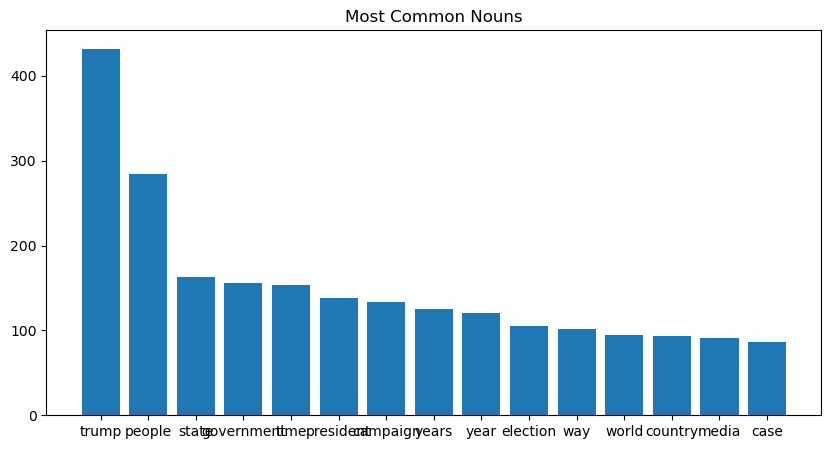

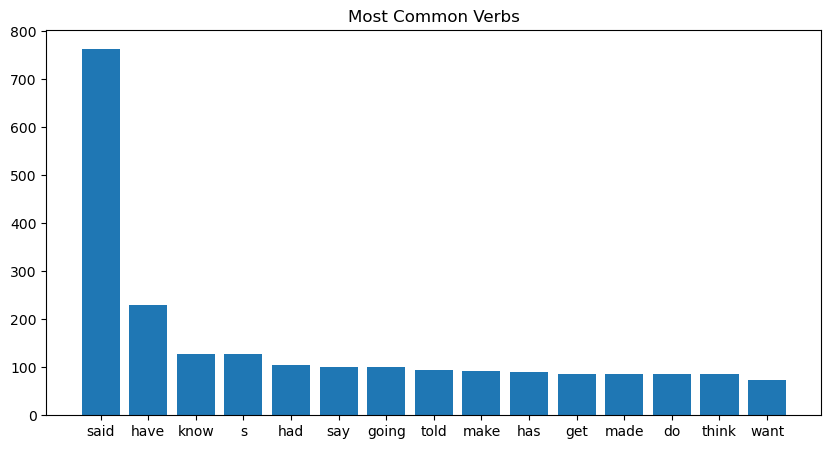

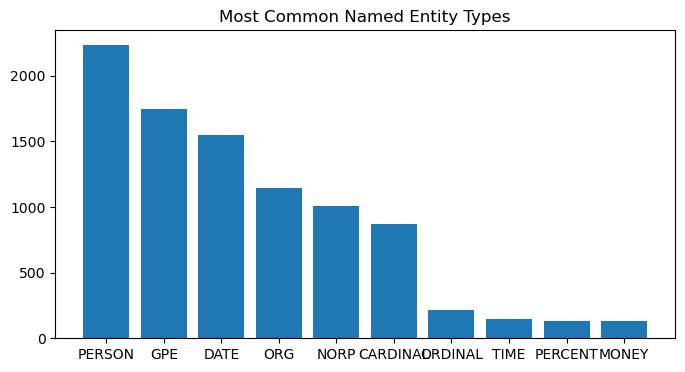

In [15]:
nlp = spacy.load("en_core_web_sm")

sample_texts = fake['content'].sample(200, random_state=42).tolist()
doc = nlp(" ".join(sample_texts))

nouns = [token.text for token in doc if token.pos_ == "NOUN" and token.is_alpha]
verbs = [token.text for token in doc if token.pos_ == "VERB" and token.is_alpha]

entities = [ent.label_ for ent in doc.ents]

noun_freq = Counter(nouns).most_common(15)
verb_freq = Counter(verbs).most_common(15)
entity_freq = Counter(entities).most_common(10)

print("top nouns:", noun_freq)
print("top verbs:", verb_freq)
print("top entity labels:", entity_freq)

#plotting
def plot_freq(data, title):
    words, counts = zip(*data)
    plt.figure(figsize=(10,5))
    plt.bar(words, counts)
    plt.title(title)
#    plt.xticks(rotation=45)
    plt.show()

plot_freq(noun_freq, "Most Common Nouns")
plot_freq(verb_freq, "Most Common Verbs")

labels_ent, counts_ent = zip(*entity_freq)
plt.figure(figsize=(8,4))
plt.bar(labels_ent, counts_ent)
plt.title("Most Common Named Entity Types")
plt.show()

For this assignment, I analyzed a sample of 200 articles from the dataset using spaCy to understand the semantic content. The most frequent nouns included `trump`, `people`, `state`, `government`, and `president`, indicating that much of the dataset focuses on U.S. politics and governance. Common verbs such as `said`, `have`, `know`, and `told` suggest a reporting style that is typical of news articles, often quoting sources or describing actions. Named entity analysis revealed that `PERSON`, `GPE`, `DATE`, `ORG`, and `NORP` were the most common entity types, which reinforces that articles center around political figures, events, and locations. These patterns show that the dataset is politically oriented and understanding the frequent nouns, verbs, and entities helps explain why certain words or phrases are important features for the TF-IDF and embedding-based classifiers. The visualizations of these frequencies further illustrate which terms are most popular in the text and key topics that the models use to distinguish between real and fake news.